In [ ]:
# 整理資料
# 匯入必要的套件
import pandas as pd

# 1. 讀取檔案：設定所有要讀取的銷售資料檔案路徑
files = [
    '電行數據-銷售_20200101 - 20231231_2020.xlsx',
    '電行數據-銷售_20200101 - 20231231_2021.xlsx',
    '電行數據-銷售_20200101 - 20231231_2022.xlsx',
    '電行數據-銷售_20200101 - 20231231_2023.xlsx'
]

# 2. 逐一讀取檔案並合併
all_data = []
for file in files:
    df = pd.read_excel(file)    # 讀取單一檔案
    all_data.append(df)         # 加入清單中

# 3. 合併所有年度的銷售資料
sales_data = pd.concat(all_data, ignore_index=True)

# 4. 挑選需要的欄位：會員編號、訂單日期、金額
rfm_data = sales_data[['會員編號', '訂單日期', '金額']].copy()

# 5. 把會員編號轉成字串，移除小數點後的.0
rfm_data['會員編號'] = rfm_data['會員編號'].astype(str).str.replace('.0', '', regex=False)

# 6. 把訂單日期轉成日期格式，方便後續計算
rfm_data['訂單日期'] = pd.to_datetime(rfm_data['訂單日期'])

# 7. 設定基準日：資料中最晚的訂單日期
reference_date = rfm_data['訂單日期'].max()

# 8. 計算每個會員的 RFM 指標
rfm_summary = rfm_data.groupby('會員編號').agg(
    第一次購買日期=('訂單日期', 'min'),     # 最早購買日期
    最後一次購買日期=('訂單日期', 'max'),   # 最晚購買日期
    Frequency=('訂單日期', 'count'),      # 購買次數
    Monetary=('金額', 'sum')             # 總消費金額
).reset_index()

# 9. 計算 Recency：距離基準日的天數
rfm_summary['Recency'] = (reference_date - rfm_summary['最後一次購買日期']).dt.days

# 10. 重新排列欄位順序
rfm_summary = rfm_summary[['會員編號', '第一次購買日期', '最後一次購買日期', 'Recency', 'Frequency', 'Monetary']]

# 11. 顯示完整的RFM結果
print(rfm_summary)

# 12. （可選）儲存成Excel檔案 (在左邊檔案裡)
rfm_summary.to_excel('RFM結果.xlsx', index=False)




               會員編號    第一次購買日期   最後一次購買日期  Recency  Frequency  Monetary
0     1000100013633 2020-02-05 2023-10-03       87         11     36104
1     1000100016061 2021-01-25 2021-01-25     1068          1      4790
2     1000100017952 2020-07-31 2020-07-31     1246          1      2040
3     1000100027098 2020-10-16 2021-01-19     1074          3      5520
4     1000100034492 2021-12-25 2021-12-25      734          1      2070
...             ...        ...        ...      ...        ...       ...
3429   990200012258 2020-04-22 2020-04-22     1346          3      1200
3430   990200015808 2021-09-30 2021-10-06      814          5     12440
3431   990200015853 2021-02-09 2021-08-28      853          3      5398
3432   990200016898 2021-03-16 2021-03-16     1018          1      8340
3433            nan 2023-06-21 2023-12-28        1         46     59396

[3434 rows x 6 columns]


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23458 (\N{CJK UNIFIED IDEOGRAPH-5BA2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25142 (\N{CJK UNIFIED IDEOGRAPH-6236}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32676 (\N{CJK UNIFIED IDEOGRAPH-7FA4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32068 (\N{CJK UNIFIED IDEOGRAPH-7D44}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


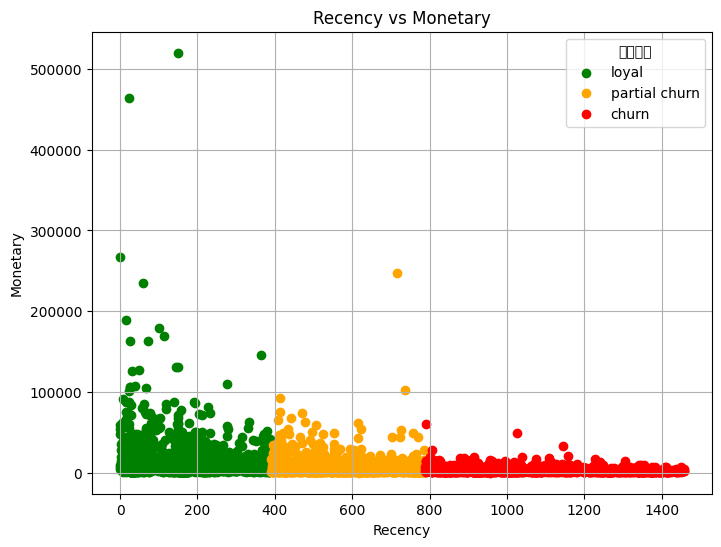

In [ ]:
#分群＆畫圖
import matplotlib.pyplot as plt

# === 根據Recency分群並繪製帶標籤的散佈圖 ===

# 建立分群標籤（loyal, partial churn, churn）
q1 = rfm_summary['Recency'].quantile(1/3) #第一四分位數
q2 = rfm_summary['Recency'].quantile(2/3)

def assign_label(recency):
    if recency <= q1:
        return 'loyal'
    elif recency <= q2:
        return 'partial churn'
    else:
        return 'churn'

rfm_summary['Group'] = rfm_summary['Recency'].apply(assign_label)

# 設定顏色對應
color_map = {'loyal': 'green', 'partial churn': 'orange', 'churn': 'red'}

# 繪製散佈圖，每個群組分開繪製，帶上標籤
plt.figure(figsize=(8,6))
for label, color in color_map.items():
    subset = rfm_summary[rfm_summary['Group'] == label]
    plt.scatter(subset['Recency'], subset['Monetary'], label=label, color=color)

plt.title('Recency vs Monetary')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.grid(True)
plt.legend(title="客戶群組", loc='upper right')
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26371 (\N{CJK UNIFIED IDEOGRAPH-6703}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21729 (\N{CJK UNIFIED IDEOGRAPH-54E1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20296 (\N{CJK UNIFIED IDEOGRAPH-4F48}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27683 (\N{CJK UNIFIED IDEOGRAPH-6C23}) missing from font(s) DejaVu Sans.
  fig.canvas

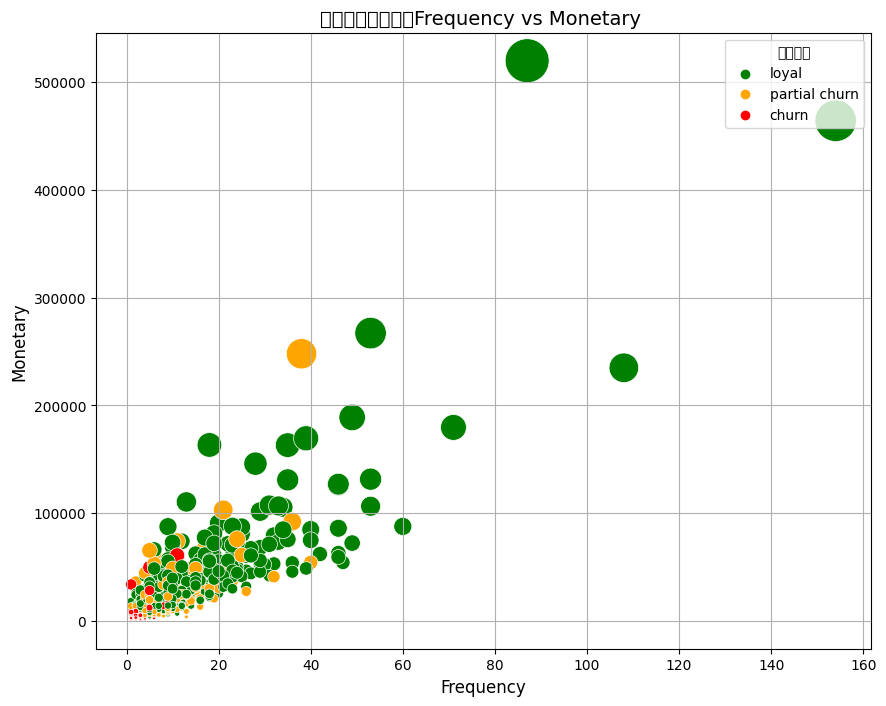

In [ ]:
# 氣泡圖：Frequency vs Monetary，氣泡大小代表消費金額

import matplotlib.pyplot as plt

# 設定氣泡大小（以Monetary金額比例縮放）
bubble_size = rfm_summary['Monetary'] / rfm_summary['Monetary'].max() * 1000

# 設定顏色（根據Group分類）
color_map = {'loyal': 'green', 'partial churn': 'orange', 'churn': 'red'}
colors = rfm_summary['Group'].map(color_map)

# 繪製氣泡圖
plt.figure(figsize=(10,8))
plt.scatter(
    rfm_summary['Frequency'],    # X軸：購買次數
    rfm_summary['Monetary'],     # Y軸：總消費金額
    s=bubble_size,               # 氣泡大小=消費金額
    c=colors,                    # 氣泡顏色
    alpha=1,
    edgecolors="w",
    linewidth=0.5
)

# 加標題與軸標籤
plt.title('會員分佈氣泡圖：Frequency vs Monetary ', fontsize=14)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Monetary', fontsize=12)
plt.grid(True)

# 加圖例（Legend），並放到右上角
for label, color in color_map.items():
    plt.scatter([], [], color=color, label=label)
plt.legend(title="客戶群組", loc='upper right')  # 這裡設定右上方

plt.show()


##4/28模型預測

In [ ]:
# 1. 載入套件
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 2. 讀取資料
file_path = 'RFM結果.xlsx'
df = pd.read_excel(file_path)

# 3. 建立是否回購欄位 (Recency小於365天視為回購)
df['是否回購'] = (df['Recency'] <= 365).astype(int)

# 4. 選取特徵與標籤
features = df[['Recency', 'Frequency', 'Monetary']].values
labels = df['是否回購'].values

# 5. 構建時序資料 (每3筆資料形成一個樣本)
time_steps = 3
X, y = [], []
for i in range(len(df) - time_steps):
    X.append(features[i:i+time_steps])
    y.append(labels[i + time_steps])

X = np.array(X)
y = to_categorical(np.array(y), num_classes=2)  # 兩類，回購(1)、未回購(0)

# 6. 拆分訓練集與測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. 建立LSTM模型
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2]), activation='relu'))
model.add(LSTM(32, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=20, verbose=1)

# 8. 預測測試資料
y_pred_prob = model.predict(X_test)
y_pred = y_pred_prob.argmax(axis=1)
y_true = y_test.argmax(axis=1)

# 9. 輸出分類結果
print(classification_report(y_true, y_pred))

# 10. 用全資料預測，並新增一欄"預測是否回購"
# 先處理新的X（用所有資料形成新的時序資料）
full_X, _ = [], []
for i in range(len(df) - time_steps):
    full_X.append(features[i:i+time_steps])

full_X = np.array(full_X)

full_pred_prob = model.predict(full_X)
full_pred = full_pred_prob.argmax(axis=1)

# 因為是從第3筆開始預測，所以新增NaN填補前幾筆
pred_result = [np.nan]*time_steps + full_pred.tolist()
df['預測是否回購'] = pred_result

# 11. 輸出前幾筆結果看看
print(df.head(10))

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5746 - loss: 63.6489
Epoch 2/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5551 - loss: 17.3269
Epoch 3/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5745 - loss: 11.3038
Epoch 4/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6032 - loss: 3.6153
Epoch 5/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5491 - loss: 2.6190
Epoch 6/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5749 - loss: 1.8897
Epoch 7/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5927 - loss: 1.2929
Epoch 8/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5880 - loss: 1.2036
Epoch 9/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5718 - loss: 1.2231
Epoch 10/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6044 - loss: 0.9108
Epoch 11/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6099 - loss: 0.8834
Epoch 12/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6373 - loss: 0.86

##Logisic Regressiion、KNN

=== A版 (RFM) - 5折交叉驗證結果 ===
第1折 - Logistic Regression Accuracy: 0.9825, KNN Accuracy: 0.9665


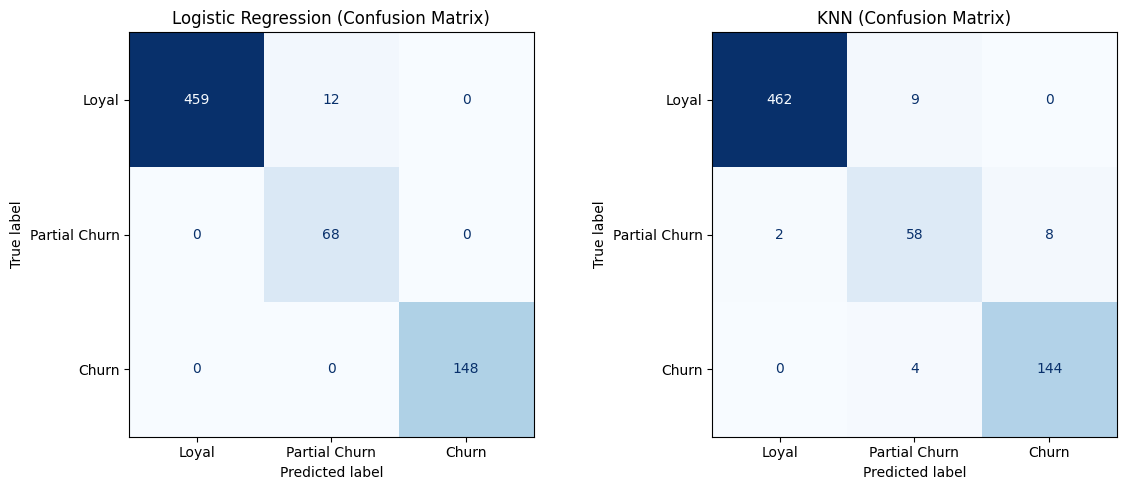

第2折 - Logistic Regression Accuracy: 0.9825, KNN Accuracy: 0.9563


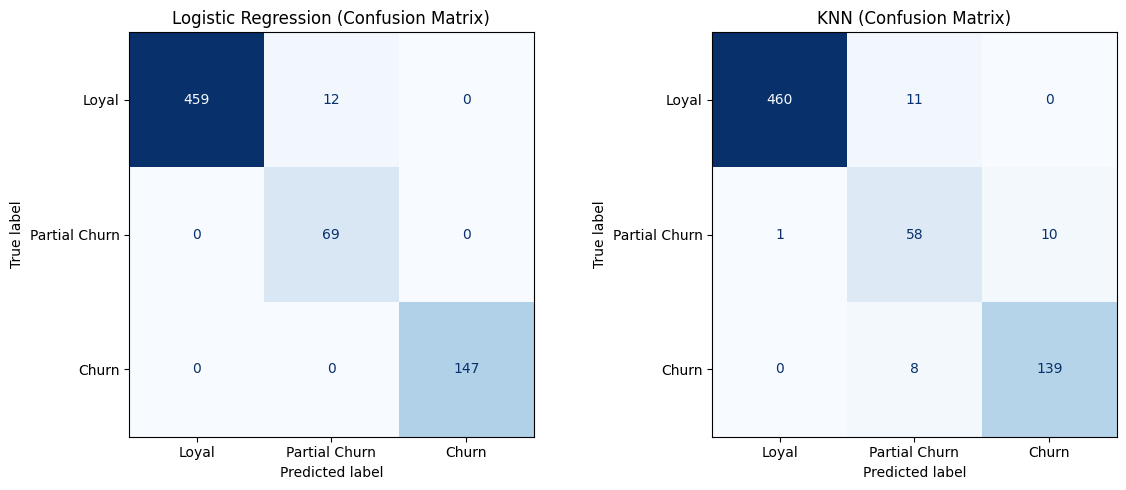

第3折 - Logistic Regression Accuracy: 0.9723, KNN Accuracy: 0.9680


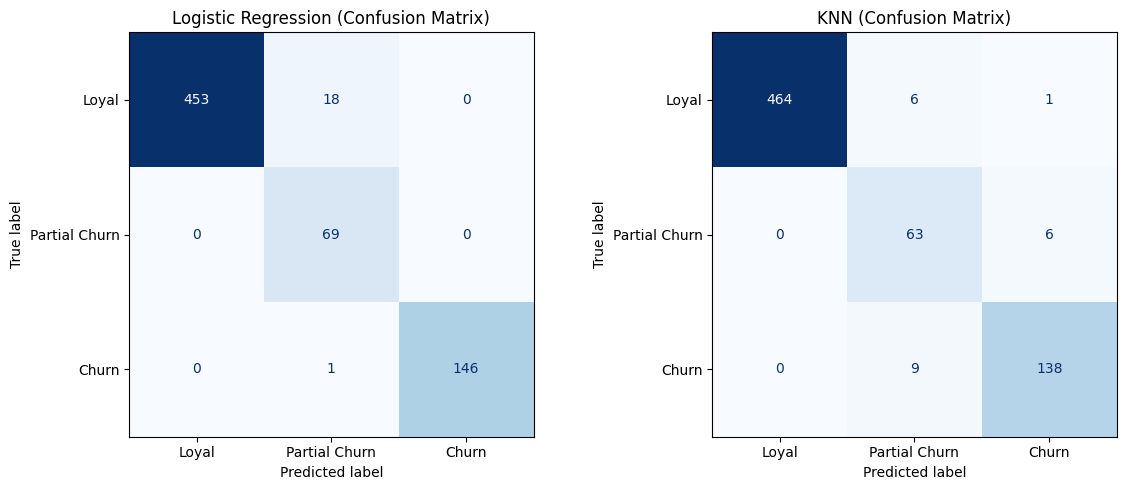

第4折 - Logistic Regression Accuracy: 0.9825, KNN Accuracy: 0.9680


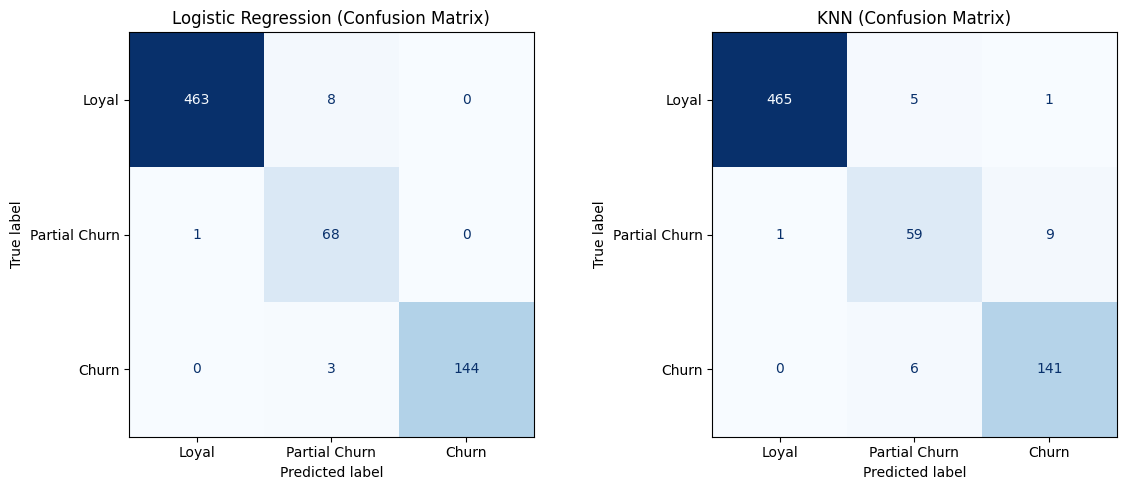

第5折 - Logistic Regression Accuracy: 0.9694, KNN Accuracy: 0.9490


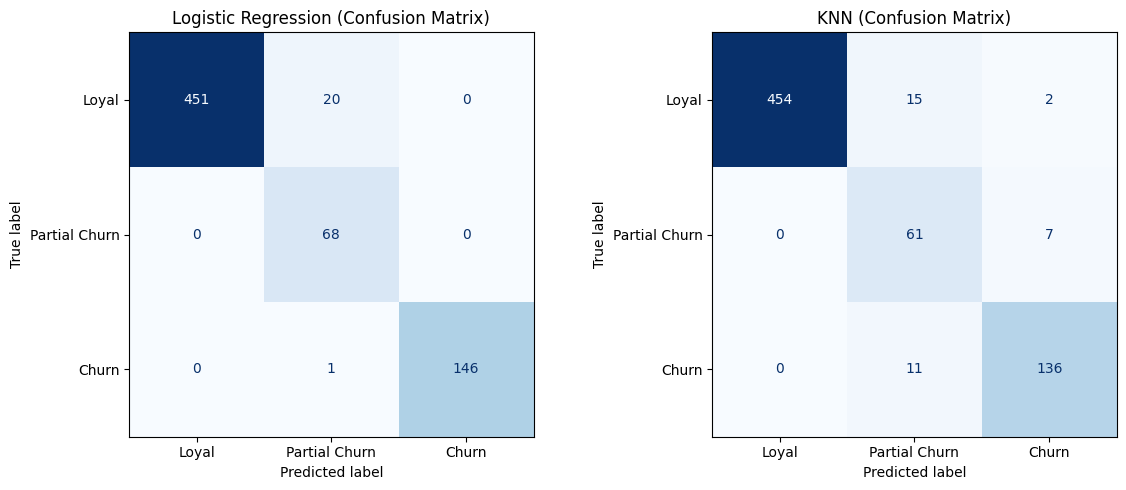

Logistic Regression 平均Accuracy: 0.9779
KNN 平均Accuracy: 0.9616

=== B版 (FM) - 5折交叉驗證結果 ===
第1折 - Logistic Regression Accuracy: 0.6434, KNN Accuracy: 0.6012


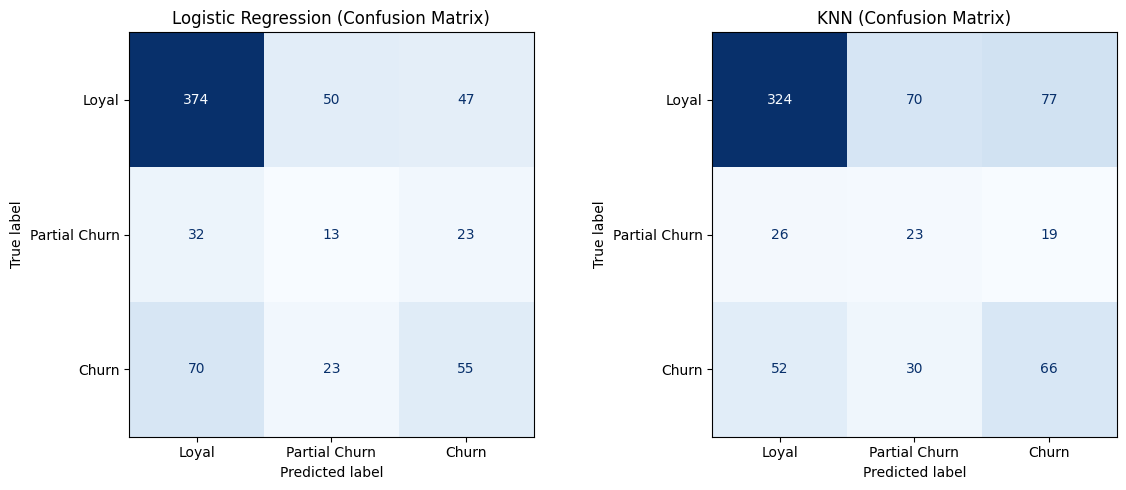

第2折 - Logistic Regression Accuracy: 0.6346, KNN Accuracy: 0.6186


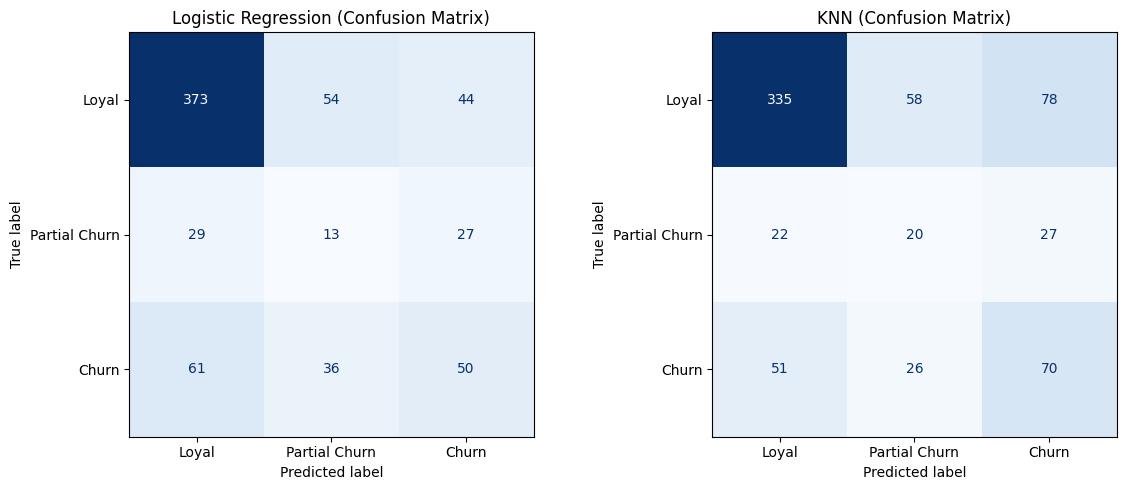

第3折 - Logistic Regression Accuracy: 0.6725, KNN Accuracy: 0.6186


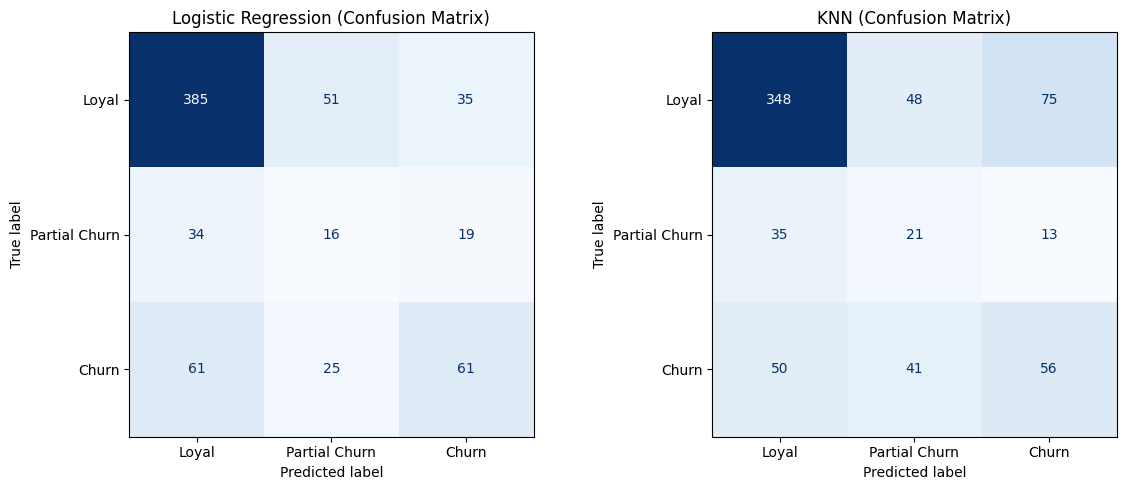

第4折 - Logistic Regression Accuracy: 0.6579, KNN Accuracy: 0.6172


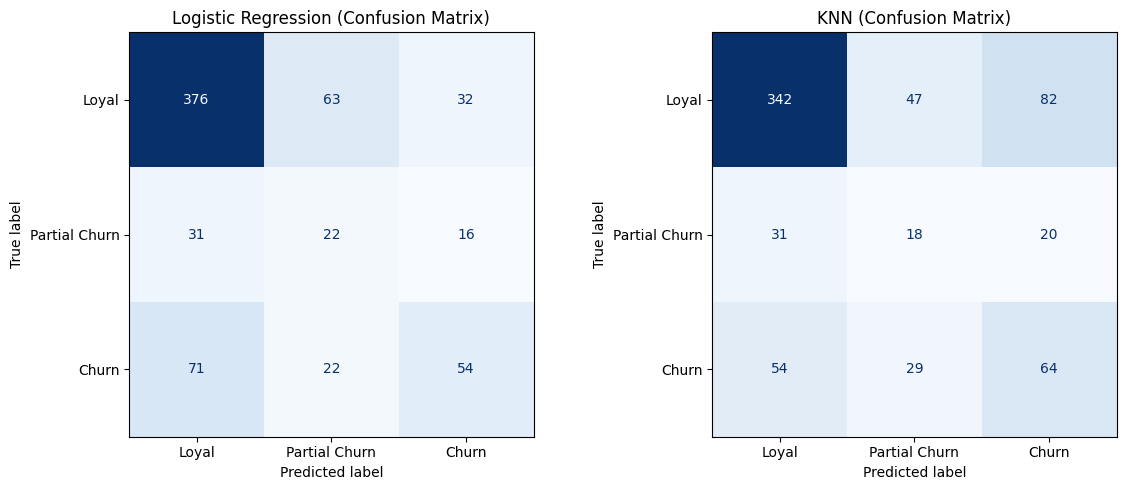

第5折 - Logistic Regression Accuracy: 0.6341, KNN Accuracy: 0.6020


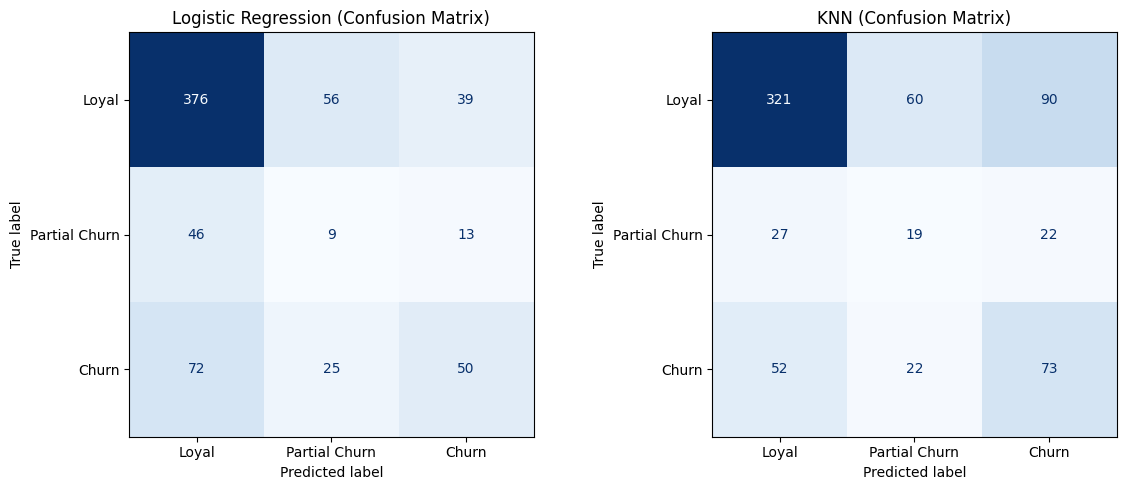

Logistic Regression 平均Accuracy: 0.6485
KNN 平均Accuracy: 0.6115



In [ ]:
# 1. 載入套件
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

# 2. 讀取資料
file_path = 'RFM結果.xlsx'
df = pd.read_excel(file_path)

# 3. 建立三分類標籤 (根據Recency)
def classify_recency(r):
    if r <= 180:
        return 2  # Churn
    elif r <= 365:
        return 1  # Partial Churn
    else:
        return 0  # Loyal

df['活躍分類'] = df['Recency'].apply(classify_recency)

# 4. 準備特徵版本 A (Recency + Frequency + Monetary)
features_A = df[['Recency', 'Frequency', 'Monetary']]
labels = df['活躍分類']

# 5. 準備特徵版本 B (Frequency + Monetary)
features_B = df[['Frequency', 'Monetary']]

# 6. 特徵標準化 (版本A & B)
scaler_A = StandardScaler()
features_A = scaler_A.fit_transform(features_A)

scaler_B = StandardScaler()
features_B = scaler_B.fit_transform(features_B)

# 7. 定義資料平衡處理函數
def balance_data(X, y):
    df_combined = pd.DataFrame(X)
    df_combined['label'] = y.values

    df_0 = df_combined[df_combined['label'] == 0]
    df_1 = df_combined[df_combined['label'] == 1]
    df_2 = df_combined[df_combined['label'] == 2]

    max_size = max(len(df_0), len(df_1), len(df_2))

    df_0_over = resample(df_0, replace=True, n_samples=max_size, random_state=42)
    df_1_over = resample(df_1, replace=True, n_samples=max_size, random_state=42)
    df_2_over = resample(df_2, replace=True, n_samples=max_size, random_state=42)

    df_balanced = pd.concat([df_0_over, df_1_over, df_2_over])
    X_balanced = df_balanced.drop('label', axis=1).values
    y_balanced = df_balanced['label'].values

    return X_balanced, y_balanced

# 8. 五折交叉驗證
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
labels_name = ['Loyal', 'Partial Churn', 'Churn']

for version_name, features in zip(['A版 (RFM)', 'B版 (FM)'], [features_A, features_B]):
    print(f"=== {version_name} - 5折交叉驗證結果 ===")
    acc_lr_list = []
    acc_knn_list = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(features, labels)):
        X_train, X_test = features[train_idx], features[test_idx]
        y_train, y_test = labels.iloc[train_idx], labels.iloc[test_idx]

        # 資料平衡
        X_train_bal, y_train_bal = balance_data(X_train, y_train)

        # Logistic Regression
        lr = LogisticRegression(max_iter=1000)
        lr.fit(X_train_bal, y_train_bal)
        y_pred_lr = lr.predict(X_test)
        acc_lr = accuracy_score(y_test, y_pred_lr)
        acc_lr_list.append(acc_lr)

        # KNN (n_neighbors=3)
        knn = KNeighborsClassifier(n_neighbors=3)
        knn.fit(X_train_bal, y_train_bal)
        y_pred_knn = knn.predict(X_test)
        acc_knn = accuracy_score(y_test, y_pred_knn)
        acc_knn_list.append(acc_knn)

        print(f"第{fold+1}折 - Logistic Regression Accuracy: {acc_lr:.4f}, KNN Accuracy: {acc_knn:.4f}")

        # 畫出每折的混淆矩陣
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
        ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr), display_labels=labels_name).plot(ax=axs[0], cmap='Blues', colorbar=False)
        axs[0].set_title('Logistic Regression (Confusion Matrix)')
        ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn), display_labels=labels_name).plot(ax=axs[1], cmap='Blues', colorbar=False)
        axs[1].set_title('KNN (Confusion Matrix)')
        plt.tight_layout()
        plt.show()

    print(f"Logistic Regression 平均Accuracy: {np.mean(acc_lr_list):.4f}")
    print(f"KNN 平均Accuracy: {np.mean(acc_knn_list):.4f}\n")


##4/29

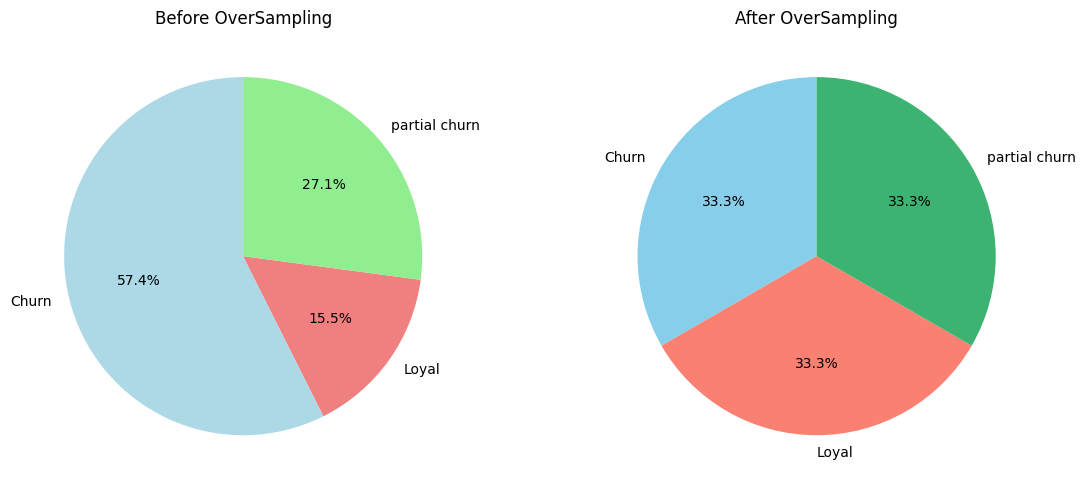

原始資料各分類數量：
Churn            3517
Loyal             949
partial churn    1661
Name: count, dtype: int64

Oversampling 後各分類數量：
Churn            3517
Loyal            3517
partial churn    3517
Name: count, dtype: int64


In [ ]:
# 需要的套件
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
import matplotlib.pyplot as plt

# 讀取資料
label_2020_2021 = pd.read_excel('2020~2021_label.xlsx')
label_2021_2022 = pd.read_excel('2021~2022_label.xlsx')
label_2022_2023 = pd.read_excel('2022~2023_label.xlsx')
label_2023_2024 = pd.read_excel('2023~2024_label.xlsx')
rfm_data = pd.read_excel('RFM分析&分級結果.xlsx')

# 整合四年 Label
label_2020_2021['year'] = '2020_2021'
label_2021_2022['year'] = '2021_2022'
label_2022_2023['year'] = '2022_2023'
label_2023_2024['year'] = '2023_2024'

label_all = pd.concat([
    label_2020_2021,
    label_2021_2022,
    label_2022_2023,
    label_2023_2024
], ignore_index=True)

# 清理欄位
label_all.columns = [col.strip() for col in label_all.columns]
rfm_data.columns = [col.strip() for col in rfm_data.columns]

# 確定客戶代號欄位名稱
customer_id_label = [col for col in label_all.columns if '客戶代號' in col][0]
customer_id_rfm = [col for col in rfm_data.columns if '客戶代號' in col][0]

label_all = label_all.rename(columns={customer_id_label: '客戶代號'})
rfm_data = rfm_data.rename(columns={customer_id_rfm: '客戶代號'})

# 合併 Label 與 RFM
merged_simple = label_all.merge(rfm_data, on='客戶代號', how='left')

# 選特徵欄位
features_simple = ['Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score']
merged_simple = merged_simple.dropna(subset=['布林值'])
X_simple = merged_simple[features_simple].fillna(0)
y_simple = merged_simple['布林值']

# Label Encoding，並將數值標籤映射到文字標籤
label_mapping = {0: 'Churn', 1: 'partial churn', 2:'Loyal'}
le_simple = LabelEncoder()
y_encoded_simple = le_simple.fit_transform(y_simple)
y_labeled_simple = pd.Series(y_encoded_simple).map(label_mapping) # 將數值標籤映射到文字標籤

# ======= 進行 OverSampling =======

# 包成 DataFrame
df_balance = pd.DataFrame(X_simple, columns=features_simple)
df_balance['label'] = y_encoded_simple

# 分群
classes = df_balance['label'].unique()
class_dfs = [df_balance[df_balance['label'] == cls] for cls in classes]
max_count = max(len(cdf) for cdf in class_dfs)

# 隨機重抽樣
upsampled_dfs = [resample(cdf, replace=True, n_samples=max_count, random_state=42) for cdf in class_dfs]
df_upsampled = pd.concat(upsampled_dfs)

# 從過採樣後的 DataFrame 中取得 y_balanced
y_balanced = df_upsampled['label'].values  # 從 df_upsampled 取得 y_balanced

# Oversampling 後的 y，並將數值標籤映射到文字標籤
y_balanced_labeled = pd.Series(y_balanced).map(label_mapping) # 將數值標籤映射到文字標籤

# ======= 畫圓餅圖 =======

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 原始資料分布
original_counts = y_labeled_simple.value_counts().sort_index() # 使用文字標籤計算數量
axes[0].pie(original_counts, labels=original_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral', 'lightgreen'])
axes[0].set_title("Before OverSampling")

# 平衡後資料分布
balanced_counts = y_balanced_labeled.value_counts().sort_index() # 使用文字標籤計算數量
axes[1].pie(balanced_counts, labels=balanced_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon', 'mediumseagreen'])
axes[1].set_title("After OverSampling")

plt.tight_layout()
plt.show()

# 顯示各分類資料數量
print("原始資料各分類數量：")
print(original_counts)
print("\nOversampling 後各分類數量：")
print(balanced_counts)

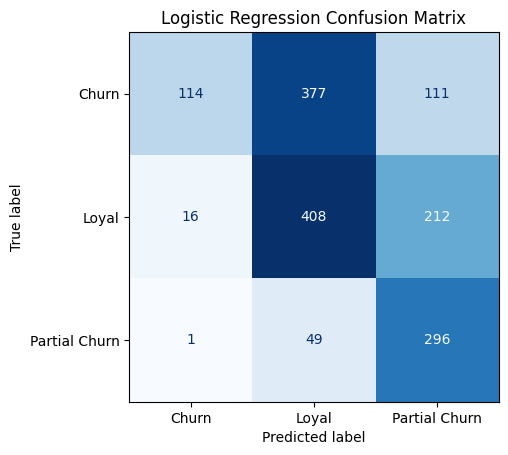


Classification Report for Logistic Regression:
               precision    recall  f1-score   support

        churn       0.87      0.19      0.31       602
        loyal       0.49      0.64      0.56       636
partial churn       0.48      0.86      0.61       346

     accuracy                           0.52      1584
    macro avg       0.61      0.56      0.49      1584
 weighted avg       0.63      0.52      0.48      1584

5-Fold CV Accuracy for Logistic Regression: 0.6698 ± 0.0087


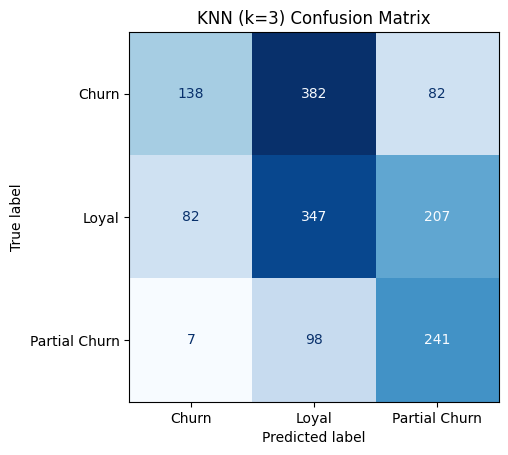


Classification Report for KNN (k=3):
               precision    recall  f1-score   support

        churn       0.61      0.23      0.33       602
        loyal       0.42      0.55      0.47       636
partial churn       0.45      0.70      0.55       346

     accuracy                           0.46      1584
    macro avg       0.49      0.49      0.45      1584
 weighted avg       0.50      0.46      0.44      1584

5-Fold CV Accuracy for KNN (k=3): 0.6071 ± 0.0138


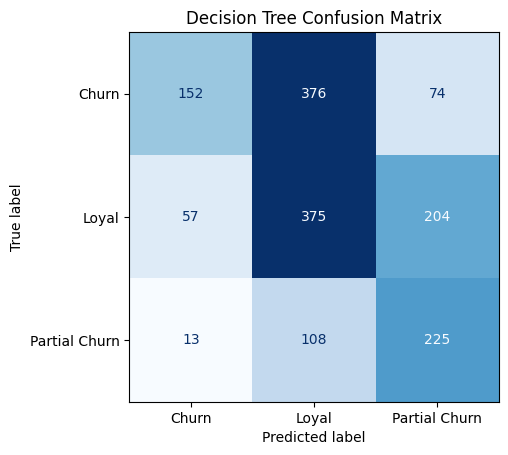


Classification Report for Decision Tree:
               precision    recall  f1-score   support

        churn       0.68      0.25      0.37       602
        loyal       0.44      0.59      0.50       636
partial churn       0.45      0.65      0.53       346

     accuracy                           0.47      1584
    macro avg       0.52      0.50      0.47      1584
 weighted avg       0.53      0.47      0.46      1584

5-Fold CV Accuracy for Decision Tree: 0.5754 ± 0.0087


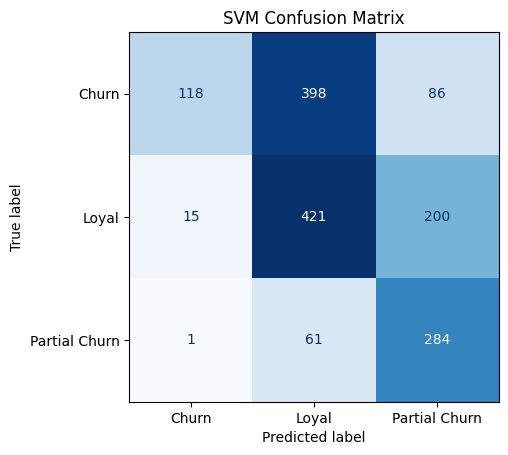


Classification Report for SVM:
               precision    recall  f1-score   support

        churn       0.88      0.20      0.32       602
        loyal       0.48      0.66      0.56       636
partial churn       0.50      0.82      0.62       346

     accuracy                           0.52      1584
    macro avg       0.62      0.56      0.50      1584
 weighted avg       0.64      0.52      0.48      1584

5-Fold CV Accuracy for SVM: 0.6742 ± 0.0190


In [ ]:
# 資料平衡處理與模型訓練 + 混淆矩陣繪製（含標準化 + 分類報告 + K-fold 交叉驗證）

# 匯入必要的套件
import pandas as pd
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt

# Step -1: 讀取並整合資料（合併不同年份的標籤資料與RFM特徵）
label_2020_2021 = pd.read_excel("2020~2021_label.xlsx")
label_2021_2022 = pd.read_excel("2021~2022_label.xlsx")
label_2022_2023 = pd.read_excel("2022~2023_label.xlsx")
label_2023_2024 = pd.read_excel("2023~2024_label.xlsx")
rfm_data = pd.read_excel("RFM分析&分級結果.xlsx")

label_2020_2021["year"] = "2020_2021"
label_2021_2022["year"] = "2021_2022"
label_2022_2023["year"] = "2022_2023"
label_2023_2024["year"] = "2023_2024"

label_all = pd.concat([label_2020_2021, label_2021_2022, label_2022_2023, label_2023_2024])
label_all["客戶代號"] = label_all["客戶代號"].astype(str)
rfm_data["客戶代號"] = rfm_data["客戶代號"].astype(str)
merged_data = pd.merge(label_all, rfm_data, on="客戶代號", how="inner")

feature_columns = ["Recency", "Frequency", "Monetary", "R_Score", "F_Score", "M_Score"]

# Step 0: 拆分訓練資料與測試資料
train_data = merged_data[merged_data["year"].isin(["2020_2021", "2021_2022", "2022_2023"])]
test_data = merged_data[merged_data["year"] == "2023_2024"]
train_data = train_data.drop(columns=["year"])
test_data = test_data.drop(columns=["year"])

# Step 1: 資料下採樣平衡分類
class_0 = train_data[train_data["布林值"] == 0]
class_1 = train_data[train_data["布林值"] == 1]
class_2 = train_data[train_data["布林值"] == 2]
min_size = min(len(class_0), len(class_1), len(class_2))
class_0_balanced = resample(class_0, replace=False, n_samples=min_size, random_state=42)
class_1_balanced = resample(class_1, replace=False, n_samples=min_size, random_state=42)
class_2_balanced = resample(class_2, replace=False, n_samples=min_size, random_state=42)
train_balanced = pd.concat([class_0_balanced, class_1_balanced, class_2_balanced])

# Step 2: 拆分特徵與標籤
X_train = train_balanced[feature_columns]
y_train = train_balanced["布林值"]
X_test = test_data[feature_columns]
y_test = test_data["布林值"]

# Step 3: 標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: 模型定義
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN (k=3)": KNeighborsClassifier(n_neighbors=3),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC()
}

# Step 5: 模型訓練 + 評估 + 混淆矩陣 + 分類報告 + 5折交叉驗證
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # 混淆矩陣
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Churn", "Loyal", "Partial Churn"],
        cmap='Blues',
        colorbar=False
    )
    plt.title(f"{name} Confusion Matrix")
    plt.grid(False)
    plt.show()

    # 分類報告
    print(f"\nClassification Report for {name}:")
    print(classification_report(y_test, y_pred, target_names=["churn", "loyal", "partial churn"]))

    # K-fold 交叉驗證（5折）在訓練集上
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    print(f"5-Fold CV Accuracy for {name}: {scores.mean():.4f} ± {scores.std():.4f}")


In [ ]:
# 讀取 test.xlsx（只有會員編號）
test_df = pd.read_excel("test.xlsx")
test_df["會員編號"] = test_df["會員編號"].astype(str)

# 從 RFM 特徵中找出這些會員對應的資料
rfm_test = rfm_data[rfm_data["客戶代號"].isin(test_df["會員編號"])]
rfm_test = rfm_test.set_index("客戶代號").reindex(test_df["會員編號"]).reset_index()

# 擷取特徵欄位，若有缺值則補為 0
test_X = rfm_test[feature_columns].fillna(0)

# 對特徵進行標準化（使用先前訓練集的 scaler）
test_X_scaled = scaler.transform(test_X)

# 進行預測
test_pred = model.predict(test_X_scaled)

# ===== 轉換標籤數值為文字，輸出結果 =====

# 轉換對應的文字標籤
label_mapping = {0: "Churn", 1: "Loyal", 2: "Partial Churn"}
test_result = pd.DataFrame({
    "客戶代號": test_df["會員編號"],
    "預測分類": test_pred
})
test_result["預測分類名稱"] = test_result["預測分類"].map(label_mapping)

# 輸出為 Excel 檔案
test_result[["客戶代號", "預測分類名稱"]].to_excel("test_prediction_results.xlsx", index=False)

# 顯示前幾筆結果
print(test_result.head())


            客戶代號  預測分類         預測分類名稱
0    20211009170     2  Partial Churn
1    20190126060     2  Partial Churn
2   990100844263     2  Partial Churn
3  1030000014980     0          Churn
4  1041001124745     2  Partial Churn


##5/12

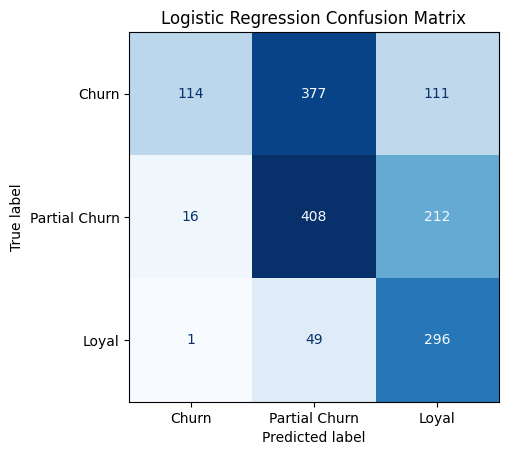


Classification Report for Logistic Regression:
               precision    recall  f1-score   support

        churn       0.87      0.19      0.31       602
partial churn       0.49      0.64      0.56       636
        loyal       0.48      0.86      0.61       346

     accuracy                           0.52      1584
    macro avg       0.61      0.56      0.49      1584
 weighted avg       0.63      0.52      0.48      1584

5-Fold CV Accuracy for Logistic Regression: 0.6698 ± 0.0087


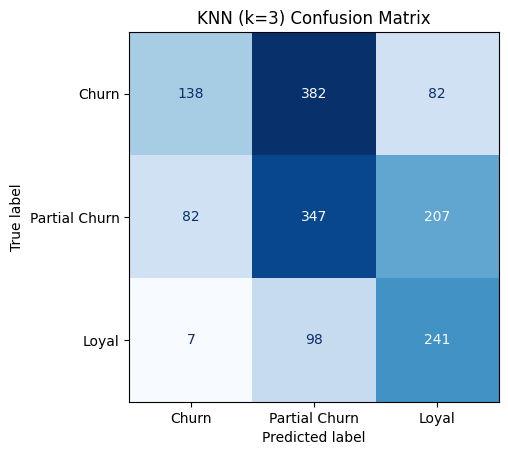


Classification Report for KNN (k=3):
               precision    recall  f1-score   support

        churn       0.61      0.23      0.33       602
partial churn       0.42      0.55      0.47       636
        loyal       0.45      0.70      0.55       346

     accuracy                           0.46      1584
    macro avg       0.49      0.49      0.45      1584
 weighted avg       0.50      0.46      0.44      1584

5-Fold CV Accuracy for KNN (k=3): 0.6071 ± 0.0138


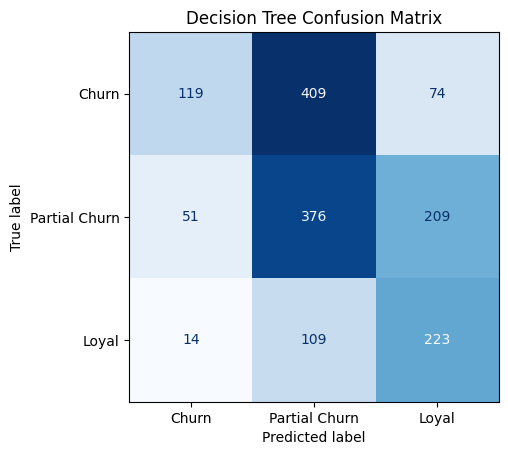


Classification Report for Decision Tree:
               precision    recall  f1-score   support

        churn       0.65      0.20      0.30       602
partial churn       0.42      0.59      0.49       636
        loyal       0.44      0.64      0.52       346

     accuracy                           0.45      1584
    macro avg       0.50      0.48      0.44      1584
 weighted avg       0.51      0.45      0.43      1584

5-Fold CV Accuracy for Decision Tree: 0.5744 ± 0.0069


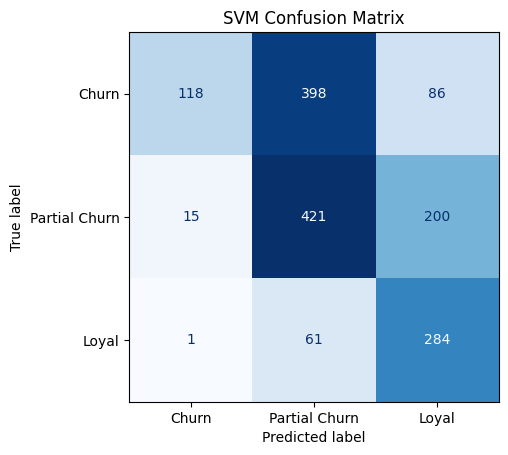


Classification Report for SVM:
               precision    recall  f1-score   support

        churn       0.88      0.20      0.32       602
partial churn       0.48      0.66      0.56       636
        loyal       0.50      0.82      0.62       346

     accuracy                           0.52      1584
    macro avg       0.62      0.56      0.50      1584
 weighted avg       0.64      0.52      0.48      1584

5-Fold CV Accuracy for SVM: 0.6742 ± 0.0190


In [ ]:
# 重新設定訓練資料與測試資料來源，加入通話與銷售特徵，並以 2020~2023 為訓練集，2023~2024 為測試集

# 匯入必要的套件
import pandas as pd
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
# 讀取四年標籤資料與 RFM 特徵
label_2020_2021 = pd.read_excel("2020~2021_label.xlsx")
label_2021_2022 = pd.read_excel("2021~2022_label.xlsx")
label_2022_2023 = pd.read_excel("2022~2023_label.xlsx")
label_2023_2024 = pd.read_excel("2023~2024_label.xlsx")
rfm_data = pd.read_excel("RFM分析&分級結果.xlsx")
sales_call_clean = pd.read_excel("sales&call_clean.xlsx")

# 設定年份欄位
label_2020_2021["year"] = "2020_2021"
label_2021_2022["year"] = "2021_2022"
label_2022_2023["year"] = "2022_2023"
label_2023_2024["year"] = "2023_2024"

# 合併標籤資料
label_all = pd.concat([label_2020_2021, label_2021_2022, label_2022_2023, label_2023_2024])
label_all["客戶代號"] = label_all["客戶代號"].astype(str)
rfm_data["客戶代號"] = rfm_data["客戶代號"].astype(str)

# 彙整 sale & call 資料前 8000 筆，計算額外特徵
sales_call = pd.read_excel("sales&call_clean.xlsx")
sales_call["客戶代號_y"] = sales_call["客戶代號_y"].astype(str)
agg_call_sales = sales_call.groupby("客戶代號_y").agg({
    "發票金額": "sum",
    "數量": "sum",
    "單價": "mean",
    "通話時間(秒)": ["sum", "mean", "count"],
    "通話狀態2": lambda x: sum(x == "舊產品續用(下訂單)")
}).reset_index()

# 重命名欄位
agg_call_sales.columns = [
    "客戶代號", "total_invoice_amount", "total_quantity", "average_unit_price",
    "total_call_duration", "average_call_duration", "call_count", "successful_contact_count"
]
agg_call_sales["客戶代號"] = agg_call_sales["客戶代號"].astype(str)

# 整合特徵資料進 RFM
rfm_combined = pd.merge(rfm_data, agg_call_sales, on="客戶代號", how="left")
rfm_combined.fillna(0, inplace=True)

# 合併標籤與特徵
merged_data = pd.merge(label_all, rfm_combined, on="客戶代號", how="inner")

# 拆分 train/test
train_data = merged_data[merged_data["year"].isin(["2020_2021", "2021_2022", "2022_2023"])]
test_data = merged_data[merged_data["year"] == "2023_2024"]
train_data = train_data.drop(columns=["year"])
test_data = test_data.drop(columns=["year"])

# 下採樣平衡
class_0 = train_data[train_data["布林值"] == 0]
class_1 = train_data[train_data["布林值"] == 1]
class_2 = train_data[train_data["布林值"] == 2]
min_size = min(len(class_0), len(class_1), len(class_2))
train_balanced = pd.concat([
    resample(class_0, replace=False, n_samples=min_size, random_state=42),
    resample(class_1, replace=False, n_samples=min_size, random_state=42),
    resample(class_2, replace=False, n_samples=min_size, random_state=42)
])

# 選擇所有特徵欄位（排除非特徵欄）
exclude_cols = ["客戶代號", "Segment", "RFM_Score", "布林值"]
feature_columns = [col for col in rfm_combined.columns if col not in exclude_cols]

# 特徵與標籤
X_train = train_balanced[feature_columns]
y_train = train_balanced["布林值"]
X_test = test_data[feature_columns]
y_test = test_data["布林值"]

# 標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 模型定義
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score

import matplotlib.pyplot as plt

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN (k=3)": KNeighborsClassifier(n_neighbors=3),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC()
}

# 訓練與評估
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # 混淆矩陣圖
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Churn", "Partial Churn", "Loyal"],
        cmap='Blues',
        colorbar=False
    )
    plt.title(f"{name} Confusion Matrix")
    plt.grid(False)
    plt.show()

    # 分類報告與交叉驗證
    report = classification_report(y_test, y_pred, target_names=["churn", "partial churn", "loyal"], output_dict=True)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    print(f"\nClassification Report for {name}:")
    print(classification_report(y_test, y_pred, target_names=["churn", "partial churn", "loyal"]))
    print(f"5-Fold CV Accuracy for {name}: {scores.mean():.4f} ± {scores.std():.4f}")


In [ ]:
# 重新設定訓練資料與測試資料來源，加入通話與銷售特徵，並以 2020~2023 為訓練集，2023~2024 為測試集

# 匯入必要的套件
import pandas as pd
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
# 讀取四年標籤資料與 RFM 特徵
label_2020_2021 = pd.read_excel("2020~2021_label.xlsx")
label_2021_2022 = pd.read_excel("2021~2022_label.xlsx")
label_2022_2023 = pd.read_excel("2022~2023_label.xlsx")
label_2023_2024 = pd.read_excel("2023~2024_label.xlsx")
rfm_data = pd.read_excel("RFM分析&分級結果.xlsx")
sales_call_clean = pd.read_excel("sales&call_clean.xlsx")

# 設定年份欄位
label_2020_2021["year"] = "2020_2021"
label_2021_2022["year"] = "2021_2022"
label_2022_2023["year"] = "2022_2023"
label_2023_2024["year"] = "2023_2024"

# 合併標籤資料
label_all = pd.concat([label_2020_2021, label_2021_2022, label_2022_2023, label_2023_2024])
label_all["客戶代號"] = label_all["客戶代號"].astype(str)
rfm_data["客戶代號"] = rfm_data["客戶代號"].astype(str)

# 彙整 sale & call 資料前 8000 筆，計算額外特徵
sales_call = pd.read_excel("sales&call_clean.xlsx")
sales_call["客戶代號_y"] = sales_call["客戶代號_y"].astype(str)
agg_call_sales = sales_call.groupby("客戶代號_y").agg({
    "發票金額": "sum",
    "數量": "sum",
    "單價": "mean",
    "通話時間(秒)": ["sum", "mean", "count"],
    "通話狀態2": lambda x: sum(x == "舊產品續用(下訂單)")
}).reset_index()

# 重命名欄位
agg_call_sales.columns = [
    "客戶代號", "total_invoice_amount", "total_quantity", "average_unit_price",
    "total_call_duration", "average_call_duration", "call_count", "successful_contact_count"
]
agg_call_sales["客戶代號"] = agg_call_sales["客戶代號"].astype(str)

# 整合特徵資料進 RFM
rfm_combined = pd.merge(rfm_data, agg_call_sales, on="客戶代號", how="left")
rfm_combined.fillna(0, inplace=True)

# 合併標籤與特徵
merged_data = pd.merge(label_all, rfm_combined, on="客戶代號", how="inner")

# 拆分 train/test
train_data = merged_data[merged_data["year"].isin(["2020_2021", "2021_2022", "2022_2023"])]
test_data = merged_data[merged_data["year"] == "2023_2024"]
train_data = train_data.drop(columns=["year"])
test_data = test_data.drop(columns=["year"])

# 下採樣平衡
class_0 = train_data[train_data["布林值"] == 0]
class_1 = train_data[train_data["布林值"] == 1]
class_2 = train_data[train_data["布林值"] == 2]
min_size = min(len(class_0), len(class_1), len(class_2))
train_balanced = pd.concat([
    resample(class_0, replace=False, n_samples=min_size, random_state=42),
    resample(class_1, replace=False, n_samples=min_size, random_state=42),
    resample(class_2, replace=False, n_samples=min_size, random_state=42)
])

# 選擇所有特徵欄位（排除非特徵欄）
exclude_cols = ["客戶代號", "Segment", "RFM_Score", "布林值"]
feature_columns = [col for col in rfm_combined.columns if col not in exclude_cols]

# 特徵與標籤
X_train = train_balanced[feature_columns]
y_train = train_balanced["布林值"]
X_test = test_data[feature_columns]
y_test = test_data["布林值"]

# 標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 模型定義
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score

import matplotlib.pyplot as plt

models = {
    "Logistic Regression": LogisticRegression(C=0.1, max_iter=1000),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5, weights='distance'),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, min_samples_split=10, criterion='entropy'),
    "SVM": SVC(C=1.0, kernel='rbf', gamma='scale')
}

# 訓練與評估
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # 混淆矩陣圖
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Churn", "Partial Churn", "Loyal"],
        cmap='Blues',
        colorbar=False
    )
    plt.title(f"{name} Confusion Matrix")
    plt.grid(False)
    plt.show()

    # 分類報告與交叉驗證
    report = classification_report(y_test, y_pred, target_names=["churn", "partial churn", "loyal"], output_dict=True)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    print(f"\nClassification Report for {name}:")
    print(classification_report(y_test, y_pred, target_names=["churn", "partial churn", "loyal"]))
    print(f"5-Fold CV Accuracy for {name}: {scores.mean():.4f} ± {scores.std():.4f}")

FileNotFoundError: [Errno 2] No such file or directory: 'sales&call_clean.xlsx'